In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.gridspec as gridspec
from scipy.optimize import fsolve

# ==================== 全局配置参数 ====================
# 网络参数
N_NODES = 30  # 节点数量
AVG_DEGREES = [3, 4, 6]  # 目标平均度
GAMMA = 3.5  # 幂律指数

# 可视化参数
NODE_SIZE = 10  # 节点大小
NODE_LINEWIDTH = 0.5  # 节点边框宽度
EDGE_WIDTH = 0.5  # 边宽度
EDGE_ALPHA = 0.4  # 边透明度
SEED = 41  # 随机种子

# Nature Communication 风格配色
COLORS = ['#F18F01', '#A23B72', '#2E86AB']  # Nature风格的颜色
BG_COLOR = '#F8F9FA'  # 背景色

# ==================== 无标度网络生成模块 ====================
def generate_scale_free_network(n_nodes, target_avg_degree, gamma, seed):
    """生成无标度网络（配置模型）"""
    np.random.seed(seed)
    
    # 生成幂律度分布
    # 使用离散幂律分布，最小度为1
    k_min = 1
    k_max = n_nodes - 1
    
    # 生成幂律序列直到总和满足目标
    degree_sum = 0
    degrees = []
    attempts = 0
    max_attempts = 1000
    
    while degree_sum < target_avg_degree * n_nodes and attempts < max_attempts:
        # 生成一个幂律分布的度序列
        # 使用离散幂律分布：P(k) ∝ k^{-gamma}
        k_values = np.arange(k_min, k_max + 1)
        probs = k_values ** (-gamma)
        probs = probs / probs.sum()
        
        degrees = np.random.choice(k_values, size=n_nodes, p=probs)
        degree_sum = degrees.sum()
        attempts += 1
    
    # 如果尝试次数过多，使用简单方法
    if attempts >= max_attempts:
        # 使用线性调整
        degrees = np.ones(n_nodes, dtype=int)
        while degrees.sum() < target_avg_degree * n_nodes:
            idx = np.random.randint(0, n_nodes)
            degrees[idx] += 1
    
    # 确保度序列之和为偶数（配置模型要求）
    if degrees.sum() % 2 != 0:
        degrees[np.random.randint(0, n_nodes)] += 1
    
    # 使用配置模型生成网络
    G = nx.configuration_model(degrees, seed=seed)
    
    # 转换为简单图（移除自环和多重边）
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    # 重新标记节点为0到n_nodes-1
    G = nx.convert_node_labels_to_integers(G)
    
    # 实际的平均度可能与目标略有不同
    actual_avg_degree = sum(dict(G.degree()).values()) / n_nodes
    
    # 如果实际平均度与目标相差太大，可以重新生成
    if abs(actual_avg_degree - target_avg_degree) > 0.5:
        # 递归调用，使用不同的种子
        return generate_scale_free_network(n_nodes, target_avg_degree, gamma, seed + 1)
    
    return G

def get_natural_layout(G, seed):
    """生成符合Nature风格的布局（保持布局一致性）"""
    np.random.seed(seed)
    n_nodes = len(G.nodes())
    
    # 根据节点度调整布局，度大的节点在中心
    degrees = dict(G.degree())
    
    # 使用spring布局进行优化，k值根据节点数调整
    k_value = 2.0 * np.sqrt(N_NODES / 40)  # 根据节点数调整斥力
    pos = nx.spring_layout(G, seed=seed, iterations=100, k=k_value)
    
    return pos

# ==================== 网络绘制模块 ====================
def draw_single_network(ax, G, pos, color, avg_degree):
    """绘制单个网络"""
    # 设置背景
    ax.set_facecolor(BG_COLOR)
    
    # 计算实际平均度
    degrees = [d for _, d in G.degree()]
    actual_avg_degree = np.mean(degrees)
    
    # 根据平均度调整边的可视化参数
    edge_width = EDGE_WIDTH
    edge_alpha = EDGE_ALPHA
    
    # 随着平均度增加，边更明显
    if avg_degree >= 5:
        edge_width = EDGE_WIDTH * 1.5
        edge_alpha = EDGE_ALPHA * 1.5
    
    # 根据节点度调整节点大小
    degrees_dict = dict(G.degree())
    node_sizes = [NODE_SIZE * (1 + 0.5 * np.log1p(degrees_dict[node])) for node in G.nodes()]
    
    # 先绘制边（在节点下面）
    nx.draw_networkx_edges(G, pos, ax=ax, 
                          alpha=edge_alpha, 
                          width=edge_width, 
                          edge_color='#666666')
    
    # 再绘制节点（在边上面）
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                          node_color=color, 
                          node_size=node_sizes, 
                          edgecolors='white', 
                          linewidths=NODE_LINEWIDTH)
    
    # 移除坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置合适的显示范围
    all_x = [pos[i][0] for i in pos]
    all_y = [pos[i][1] for i in pos]
    
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    
    # 添加边距
    density_factor = 1.0 + (avg_degree - 3) * 0.02
    x_margin = (x_max - x_min) * 0.2 / density_factor
    y_margin = (y_max - y_min) * 0.2 / density_factor
    
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    return actual_avg_degree

# ==================== 无标度网络相变理论计算 ====================
def scale_free_giant_component_theory(p, avg_k, gamma):
    """
    无标度网络中最大团簇大小的理论计算
    使用生成函数方法，适用于幂律分布
    
    参数:
    p: 节点或边保留的概率
    avg_k: 网络平均度
    gamma: 幂律指数
    """
    # 对于无标度网络，使用生成函数方法
    # 生成函数: G0(x) = sum_k p_k x^k
    # 对于连续近似，当gamma=3.5时
    
    if gamma <= 3:
        # 当gamma<=3时，网络行为不同
        if p == 0:
            return 0.0
        else:
            # 近似计算
            return min(1.0, p * (1 - (1 - p)**(avg_k-1)))
    
    # 对于gamma>3的情况，使用更精确的近似
    # 临界行为近似
    k_min = 1  # 最小度
    k_cut = 100  # 截断
    
    # 计算生成函数
    k_vals = np.arange(k_min, k_cut + 1)
    p_k = k_vals ** (-gamma)
    p_k = p_k / p_k.sum()  # 归一化
    
    # 自洽方程: u = sum_k p_k * k/avg_k * u^{k-1}
    # 其中u是随机选择的边不连接到最大团簇的概率
    
    def equation(u):
        result = 0.0
        for k, prob in zip(k_vals, p_k):
            result += prob * k / avg_k * u**(k-1)
        return u - p * result - (1-p)
    
    # 求解自洽方程
    try:
        # 初始猜测
        u_initial = 0.5 if p > 0.5 else 0.9
        
        u_solution = fsolve(equation, u_initial, full_output=True)[0][0]
        u_solution = np.clip(u_solution, 0, 1)
        
        # 计算最大团簇大小 S = 1 - sum_k p_k * u^k
        S = 0.0
        for k, prob in zip(k_vals, p_k):
            S += prob * (1 - u_solution**k)
        
        return min(1.0, max(0.0, S))
    except:
        return 0.0

def calculate_sf_critical_point(avg_k, gamma):
    """
    计算无标度网络的临界点
    对于幂律分布，临界点与gamma有关
    """
    if gamma > 3:
        # 当gamma>3时，有有限的临界点
        # 近似公式: p_c ≈ 1 - 1/(κ-1)，其中κ = <k^2>/<k>
        # 对于幂律分布，κ = <k^2>/<k>
        
        # 计算κ的近似值
        k_min = 1
        k_cut = 100
        
        k_vals = np.arange(k_min, k_cut + 1)
        p_k = k_vals ** (-gamma)
        p_k = p_k / p_k.sum()
        
        avg_k_calc = np.sum(p_k * k_vals)
        avg_k2 = np.sum(p_k * k_vals**2)
        kappa = avg_k2 / avg_k_calc
        
        p_c = 1 - 1.0 / (kappa - 1) if kappa > 1 else 0.5
        
        return max(0.0, min(1.0, p_c))
    else:
        # 当gamma<=3时，临界点为0（网络始终是连通的）
        return 0.0

# ==================== 主绘图函数 ====================
def create_scale_free_networks_figure():
    """创建无标度网络示意图（纵向排列）"""
    fig, axes = plt.subplots(3, 1, figsize=(2, 3))
    
    networks = []
    positions = []
    actual_degrees = []
    
    base_seed = SEED
    for i, target_avg_degree in enumerate(AVG_DEGREES):
        network_seed = base_seed + i * 100
        G = generate_scale_free_network(N_NODES, target_avg_degree, GAMMA, network_seed)
        networks.append(G)
        layout_seed = network_seed
        pos = get_natural_layout(G, layout_seed)
        positions.append(pos)
    
    for i, (target_avg_degree, G, pos, color) in enumerate(zip(AVG_DEGREES, networks, positions, COLORS)):
        ax = axes[i]
        actual_degree = draw_single_network(ax, G, pos, color, target_avg_degree)
        actual_degrees.append(actual_degree)
        
    plt.tight_layout(pad=0.01, h_pad=0.01, w_pad=0.01)
    plt.show()
    
    return networks, actual_degrees

def plot_scale_free_phase_diagram():
    """绘制无标度网络最大团簇相图"""
    # 设置字体
    plt.rcParams.update({
        'font.size': 24,
        'font.family': 'sans-serif',
        'text.usetex': True,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 9,
    })
    
    fig, ax = plt.subplots(figsize=(4, 3))
    
    # 生成q的范围 (q = 1-p，攻击比例)
    q_range = np.linspace(0, 1.0, 400)
    p_range = 1.0 - q_range  # p = 1-q，保留比例
    
    # 对每个平均度值计算理论曲线
    for idx, avg_k in enumerate(AVG_DEGREES):
        S_values = []
        
        # 计算临界点
        p_c = calculate_sf_critical_point(avg_k, GAMMA)
        q_c = 1.0 - p_c
        
        # 对每个p值计算理论S
        for p in p_range:
            S = scale_free_giant_component_theory(p, avg_k, GAMMA)
            S_values.append(S)
        
        # 绘制理论曲线
        ax.plot(q_range, S_values, color=COLORS[idx], 
                linewidth=3.0, alpha=0.9,
                label=f'$\\langle k \\rangle = {avg_k}$',
                zorder=3)
        
        # 标记临界点
        if 0 <= q_c <= 1:
            ax.axvline(x=q_c, color=COLORS[idx], 
                      linestyle='--', alpha=0.5, linewidth=1)
    
    # 设置坐标轴
    ax.set_xlabel('$q$', fontsize=16, loc='right', labelpad=-25)
    ax.set_ylabel('$C$', fontsize=16, loc='top', labelpad=-25, rotation=0)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels("")
    ax.set_yticklabels("")
    
    # 隐藏上、右轴线
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    # 添加箭头
    # x轴箭头
    ax.annotate('', xy=(1.1, -0.02), xycoords=('axes fraction', 'data'),
                xytext=(1.0, -0.02), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=1, shrinkA=0, shrinkB=0))

    # y轴箭头
    ax.annotate('', xy=(-0.02, 1.1), xycoords=('data', 'axes fraction'),
                xytext=(-0.02, 1.0), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=1, shrinkA=0, shrinkB=0))

    # 添加理论临界点标签
    # 根据计算出的临界点添加标签
    for idx, avg_k in enumerate(AVG_DEGREES):
        p_c = calculate_sf_critical_point(avg_k, GAMMA)
        q_c = 1.0 - p_c
        if 0.1 <= q_c <= 0.9:  # 只在合理范围内显示标签
            ax.text(q_c, 0.1 + idx*0.1, 
                   f'$q_c^{{\\langle k \\rangle ={avg_k}}} \\approx {q_c:.2f}$', 
                   color=COLORS[idx], fontsize=8, ha='center')
    
    plt.tight_layout()
    plt.show()



# ==================== 主程序 ====================
if __name__ == "__main__":
    # 1. 绘制无标度网络拓扑结构
    networks, actual_degrees = create_scale_free_networks_figure()
    
    # 2. 绘制理论相图
    print("Plotting theoretical phase diagram...")
    plot_scale_free_phase_diagram()
    
    


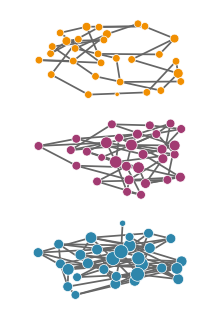

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.gridspec as gridspec
from scipy.optimize import fsolve

# ==================== 全局配置参数 ====================
# 网络参数
N_NODES = 30  # 节点数量
MIN_DEGREES = [2, 3, 4]  # 目标平均度
GAMMA = 3.5  # 幂律指数

# 可视化参数
NODE_SIZE = 10  # 节点大小
NODE_LINEWIDTH = 0.5  # 节点边框宽度
EDGE_WIDTH = 0.5  # 边宽度
EDGE_ALPHA = 0.4  # 边透明度
SEED = 41  # 随机种子

# Nature Communication 风格配色
COLORS = ['#F18F01', '#A23B72', '#2E86AB']  # Nature风格的颜色
BG_COLOR = '#F8F9FA'  # 背景色

# ==================== 无标度网络生成模块 ====================
def generate_scale_free_network(n_nodes, kmin, gamma, seed):
    """生成无标度网络（配置模型）"""
    np.random.seed(seed)
    
    # 生成幂律度分布
    # 使用离散幂律分布，最小度为1
    k_min = kmin
    k_max = n_nodes - 1
    
    # 生成幂律序列直到总和满足目标
    degree_sum = 0
    degrees = []
    
    k_values = np.arange(k_min, k_max + 1)
    probs = k_values ** (-gamma)
    probs = probs / probs.sum()
    degrees = np.random.choice(k_values, size=n_nodes, p=probs)
    degree_sum = degrees.sum() 

    # 确保度序列之和为偶数（配置模型要求）
    if degrees.sum() % 2 != 0:
        degrees[np.random.randint(0, n_nodes)] += 1
    
    # 使用配置模型生成网络
    G = nx.configuration_model(degrees, seed=seed)
    
    # 转换为简单图（移除自环和多重边）
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    # 重新标记节点为0到n_nodes-1
    G = nx.convert_node_labels_to_integers(G)
    
    return G

def get_natural_layout(G, seed):
    """生成符合Nature风格的布局（保持布局一致性）"""
    np.random.seed(seed)
    n_nodes = len(G.nodes())
    
    # 根据节点度调整布局，度大的节点在中心
    degrees = dict(G.degree())
    
    # 使用spring布局进行优化，k值根据节点数调整
    k_value = 2.0 * np.sqrt(N_NODES / 40)  # 根据节点数调整斥力
    pos = nx.spring_layout(G, seed=seed, iterations=100, k=k_value)
    
    return pos

# ==================== 网络绘制模块 ====================
def draw_single_network(ax, G, pos, color, avg_degree):
    """绘制单个网络"""
    
    # 计算实际平均度
    degrees = [d for _, d in G.degree()]
    actual_avg_degree = np.mean(degrees)
    
    # 根据平均度调整边的可视化参数
    edge_width = EDGE_WIDTH
    edge_alpha = EDGE_ALPHA
    
    # 随着平均度增加，边更明显
#    if avg_degree >= 5:
    edge_width = EDGE_WIDTH * 2.5
    edge_alpha = EDGE_ALPHA * 2.5
    
    # 根据节点度调整节点大小
    degrees_dict = dict(G.degree())
#    node_sizes = [NODE_SIZE * (1 + 2.0 * np.log1p(degrees_dict[node])) for node in G.nodes()]
    node_sizes = [NODE_SIZE * (1 + 1.0 * degrees_dict[node]) for node in G.nodes()]
    
    # 先绘制边（在节点下面）
    nx.draw_networkx_edges(G, pos, ax=ax, 
                          alpha=edge_alpha, 
                          width=edge_width, 
                          edge_color='#666666')
    
    # 再绘制节点（在边上面）
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                          node_color=color, 
                          node_size=node_sizes, 
                          edgecolors='white', 
                          linewidths=NODE_LINEWIDTH)
    
    # 移除坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置合适的显示范围
    all_x = [pos[i][0] for i in pos]
    all_y = [pos[i][1] for i in pos]
    
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    
    # 添加边距
    density_factor = 1.0 + (avg_degree - 3) * 0.02
    x_margin = (x_max - x_min) * 0.2 / density_factor
    y_margin = (y_max - y_min) * 0.2 / density_factor
    
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    return actual_avg_degree

# ==================== 主绘图函数 ====================
def create_scale_free_networks_figure():
    """创建无标度网络示意图（纵向排列）"""
    fig, axes = plt.subplots(3, 1, figsize=(2, 3))
    
    networks = []
    positions = []
    actual_degrees = []
    
    base_seed = SEED
    for i, target_avg_degree in enumerate(MIN_DEGREES):
        network_seed = base_seed + i * 100
        G = generate_scale_free_network(N_NODES, target_avg_degree, GAMMA, network_seed)
        networks.append(G)
        layout_seed = network_seed
        pos = get_natural_layout(G, layout_seed)
        positions.append(pos)
    
    for i, (target_avg_degree, G, pos, color) in enumerate(zip(MIN_DEGREES, networks, positions, COLORS)):
        ax = axes[i]
        actual_degree = draw_single_network(ax, G, pos, color, target_avg_degree)
        actual_degrees.append(actual_degree)
        
    plt.tight_layout(pad=0.01, h_pad=0.01, w_pad=0.01)
    plt.savefig("SFTopology.svg")
    plt.show()
    
    return 


if  __name__ == "__main__":

    create_scale_free_networks_figure()

3.5 2 0.6820800919482966 2.6893852513384684 11.148702152314332
3.5 3 0.8167608224811729 4.2786165803864495 27.62851717654493
3.5 4 0.8697489947442718 5.890878215111264 51.11800105800537
3.5 2 0.6820800919482966 2.6893852513384684 11.148702152314332
3.5 3 0.8167608224811729 4.2786165803864495 27.62851717654493
3.5 4 0.8697489947442718 5.890878215111264 51.11800105800537


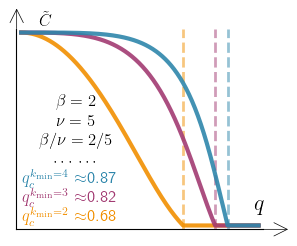

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.gridspec as gridspec
from scipy.optimize import fsolve

MIN_DEGREES = [2, 3, 4]  # 目标平均度
GAMMA = 3.5  # 幂律指数
# Nature Communication 风格配色
COLORS = ['#F18F01', '#A23B72', '#2E86AB']  # Nature风格的颜色
BG_COLOR = '#F8F9FA'  # 背景色



# ==================== 无标度网络相变理论计算 ====================
def scale_free_giant_component_theory(gamma, p, avg_k, kmin, kmax=100):
    """
    无标度网络中最大团簇大小的理论计算
    使用生成函数方法，适用于幂律分布
    
    参数:
    p: 节点或边保留的概率
    avg_k: 网络平均度
    gamma: 幂律指数
    """
    # 对于无标度网络，使用生成函数方法
    # 生成函数: G0(x) = sum_k p_k x^k
    # 对于连续近似，当gamma=3.5时
    
    if gamma <= 3:
        # 当gamma<=3时，网络行为不同
        if p == 0:
            return 0.0
        else:
            # 近似计算
            return min(1.0, p * (1 - (1 - p)**(avg_k-1)))
    
    k_min = kmin  # 最小度
    k_cut = 100  # 截断
    
    # 计算生成函数
    k_vals = np.arange(k_min, k_cut + 1)
    p_k = k_vals ** (-gamma)
    p_k = p_k / p_k.sum()  # 归一化
    
    # 自洽方程: u = sum_k p_k * k/avg_k * u^{k-1}
    # 其中u是随机选择的边不连接到最大团簇的概率
    
    def equation(u):
        result = 0.0
        for k, prob in zip(k_vals, p_k):
            result += prob * k / avg_k * u**(k-1)
        return u - p * result - (1-p)
    
    # 求解自洽方程
    try:
        # 初始猜测
        u_initial = 0.4 #if p > 0.5 else 0.9
        
        u_solution = fsolve(equation, u_initial, full_output=True)[0][0]
        u_solution = np.clip(u_solution, 0, 1)
        
        # 计算最大团簇大小 S = 1 - sum_k p_k * u^k
        S = 0.0
        for k, prob in zip(k_vals, p_k):
            S += prob * (1 - u_solution**k)
        
        return S
    except:
        return 0.0

def calculate_sf_critical_point(gamma, kmin, kmax=100):
    """
    计算无标度网络的临界点
    对于幂律分布，临界点与gamma有关
    """
    # 计算κ的近似值
    k_min = kmin 
    k_cut = kmax
    
    k_vals = np.arange(k_min, k_cut + 1)
    p_k = k_vals ** (-gamma)
    p_k = p_k / p_k.sum()
    
    avg_k  = np.sum(p_k * k_vals)
    avg_k2 = np.sum(p_k * k_vals**2)
    kappa = avg_k2 / avg_k   

    if gamma > 3:
        # 当gamma>3时，有有限的临界点
        # 近似公式: p_c ≈ 1 - 1/(κ-1)，其中κ = <k^2>/<k>
        # 对于幂律分布，κ = <k^2>/<k>
        p_c = 1 - 1.0 / (kappa - 1) if kappa > 1 else 0.5
        pc = max(0.0, min(1.0, p_c))
    else:
        pc = 0.0 

    print(gamma, kmin, pc, avg_k, avg_k2)

    return avg_k, pc

def plot_scale_free_phase_diagram():
    """绘制无标度网络最大团簇相图"""
    # 设置字体
    plt.rcParams.update({
        'font.size': 24,
        'font.family': 'sans-serif',
        'text.usetex': True,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 9,
    })
    
    fig, ax = plt.subplots(figsize=(3.5, 3))
    
    # 生成q的范围 (q = 1-p，攻击比例)
    q_range = np.linspace(0, 1.0, 400)
    p_range = 1.0 - q_range  # p = 1-q，保留比例
    
    # 对每个平均度值计算理论曲线
    for idx, kmin in enumerate(MIN_DEGREES):
        S_values = []
        
        # 计算临界点
        avg_k, p_c = calculate_sf_critical_point(GAMMA, kmin)
        q_c = 1.0 - p_c
        
        # 对每个p值计算理论S
        for p in p_range:
            S = scale_free_giant_component_theory(GAMMA, p, avg_k, kmin)
            S_values.append(S)
        
        # 绘制理论曲线
        ax.plot(q_range, S_values, color=COLORS[idx], 
                linewidth=3.0, alpha=0.9,
                label=f'$\\langle k \\rangle = {avg_k}$',
                zorder=3)
        
        # 标记临界点
        if 0 <= q_c <= 1:
            ax.axvline(x=p_c, color=COLORS[idx], linestyle='--', alpha=0.5, linewidth=2)
    
    # 设置坐标轴
    ax.set_xlabel('$q$', fontsize=16, loc='right', labelpad=-25)
    ax.set_ylabel('$\\tilde{C}$', fontsize=12, loc='top', labelpad=-25, rotation=0)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels("")
    ax.set_yticklabels("")
    
    # 隐藏上、右轴线
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    # 添加箭头
    # x轴箭头
    ax.annotate('', xy=(1.1, -0.02), xycoords=('axes fraction', 'data'),
                xytext=(1.0, -0.02), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # y轴箭头
    ax.annotate('', xy=(-0.019, 1.1), xycoords=('data', 'axes fraction'),
                xytext=(-0.019, 1.0), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # 添加理论临界点标签
    # 根据计算出的临界点添加标签
    PcArr =[]; QcArr=[]
    for idx, kmin in enumerate(MIN_DEGREES):
        avg_k, p_c = calculate_sf_critical_point(GAMMA, kmin)
        q_c = 1.0 - p_c
        PcArr.append(p_c)
        QcArr.append(q_c)
    ft1=12
    ax.text(0.2, 0.02, r"$q_c^{ k_{ \mathrm{min} } = 2 } \approx$"+f"{PcArr[0]:.2f}", color=COLORS[0], fontsize=ft1, ha='center')
    ax.text(0.2, 0.12, r"$q_c^{ k_{ \mathrm{min} } = 3 } \approx$"+f"{PcArr[1]:.2f}", color=COLORS[1], fontsize=ft1, ha='center')
    ax.text(0.2, 0.22, r"$q_c^{ k_{ \mathrm{min} } = 4 } \approx$"+f"{PcArr[2]:.2f}", color=COLORS[2], fontsize=ft1, ha='center')
    ax.text(0.23, 0.62, '$\\beta = 2$',        color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.52, '$\\nu =   5$',        color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.42, '$\\beta/\\nu = 2/5$', color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.32, '$\\cdots$ $\\cdots$', color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    
    plt.tight_layout()
    plt.savefig("SFAttack.svg")
    plt.show()



# ==================== 主程序 ====================
if __name__ == "__main__":
    
    plot_scale_free_phase_diagram()
    
    
